## 1. Introduction

This project works toward classifying static hand signs of the Nepali Sign Language (NSL) alphabet — 36 characters from the Devanagari consonant set, one per class. This notebook only explores the data that a future model will use; no neural network is built or trained here.

**Dataset.** The dataset used is the *Nepali Sign Language Character Dataset* (Poudel, Ghimire, Bhattarai, Bhandari, 2025; MIT License), published on Kaggle (https://www.kaggle.com/datasets/biratpoudelrocks/nepali-sign-language-character-dataset) and described in the accompanying paper (Poudel et al., 2026, arXiv:2510.11243). It contains 54,000 JPEG images (~1.04 GB on disk) organised into two capture conditions, a Plain Background set and a Random Background set, intended to expose a model to different lighting and background conditions. Neither the paper nor the dataset README documents the number of distinct signers or the camera/capture setup used, so those details remain unknown; Section 3 also finds that roughly 1% of images are exact duplicate frames from apparent burst capture.

**Purpose.** This notebook inspects the dataset's structure, size, class balance and image properties, checks for data-quality problems, decides whether manual feature engineering is needed, and visualises the findings — all computed directly from the files on disk, with no model built or trained here.

## 2. Load & Explore the Dataset

This section imports the libraries used throughout, locates and indexes every image file on disk, reports the dataset's basic shape and structure, and reads each image's metadata (size, mode, format) so later sections don't need to reopen files.

### Import required libraries

In [1]:
import os
import hashlib
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11

# Folder to hold the figures generated for the report
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("Libraries loaded. Figures will be saved to:", os.path.abspath(FIG_DIR))

Libraries loaded. Figures will be saved to: c:\Users\sshre\OneDrive\Desktop\Deep Learning\figures


### Locate and index the dataset

We don't assume the folder layout ahead of time. The cell below searches the `archive/` directory for the folder that contains the sign-character sub-folders, and reports what it finds — the on-disk format, number of images, classes and per-class counts.

In [2]:
def find_dataset_root(start="archive"):
    # Return the first directory that directly contains the
    # 'Plain Background' / 'Random Background' sub-folders.
    for current, subdirs, _ in os.walk(start):
        names = set(subdirs)
        if {"Plain Background", "Random Background"} & names:
            return current
    raise FileNotFoundError("Could not locate the sign-character folders under " + start)

DATA_ROOT = find_dataset_root("archive")
print("Dataset root found at:", DATA_ROOT)
print()
print("Top-level contents of the dataset root:")
for name in sorted(os.listdir(DATA_ROOT)):
    full = os.path.join(DATA_ROOT, name)
    kind = "dir " if os.path.isdir(full) else "file"
    print(f"  [{kind}] {name}")

Dataset root found at: archive\NSL\NSL

Top-level contents of the dataset root:
  [file] LICENSE
  [dir ] Plain Background
  [file] README.md
  [dir ] Random Background


In [3]:
# On-disk size of the dataset (sum of file sizes under DATA_ROOT)
total_bytes = 0
n_files_on_disk = 0
for current, _, files in os.walk(DATA_ROOT):
    for fname in files:
        total_bytes += os.path.getsize(os.path.join(current, fname))
        n_files_on_disk += 1

print(f"Files on disk      : {n_files_on_disk:,}")
print(f"Total size on disk : {total_bytes / 1e6:,.1f} MB  ({total_bytes / 1e9:.2f} GB)")

Files on disk      : 54,002
Total size on disk : 1,042.6 MB  (1.04 GB)


In [4]:
# Build an index of every image file: (filepath, background type, class folder)
records = []
for background in sorted(os.listdir(DATA_ROOT)):
    bg_path = os.path.join(DATA_ROOT, background)
    if not os.path.isdir(bg_path):
        continue
    for class_folder in sorted(os.listdir(bg_path), key=lambda x: int(x) if x.isdigit() else x):
        cls_path = os.path.join(bg_path, class_folder)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            records.append({
                "filepath": os.path.join(cls_path, fname),
                "filename": fname,
                "background": background,
                "class_folder": class_folder,
                "extension": os.path.splitext(fname)[1].lower(),
            })

df = pd.DataFrame(records)
df["class_id"] = df["class_folder"].astype(int)
print("Total image files indexed:", len(df))
print("File extensions present :", dict(Counter(df["extension"])))
print("Background types         :", sorted(df["background"].unique()))
print("Number of class folders  :", df["class_id"].nunique())
df.head()

Total image files indexed: 54000
File extensions present : {'.jpg': 54000}
Background types         : ['Plain Background', 'Random Background']
Number of class folders  : 36


,filepath,filename,background,class_folder,extension,class_id
0,archive\NSL\NSL\Plain Background\0\0.jpg,0.jpg,Plain Background,0,.jpg,0
1,archive\NSL\NSL\Plain Background\0\1.jpg,1.jpg,Plain Background,0,.jpg,0
2,archive\NSL\NSL\Plain Background\0\10.jpg,10.jpg,Plain Background,0,.jpg,0
3,archive\NSL\NSL\Plain Background\0\100.jpg,100.jpg,Plain Background,0,.jpg,0
4,archive\NSL\NSL\Plain Background\0\101.jpg,101.jpg,Plain Background,0,.jpg,0


### Dataset size and structure

In [5]:
n_images = len(df)
n_classes = df["class_id"].nunique()
n_backgrounds = df["background"].nunique()
print(f"Total images         : {n_images:,}")
print(f"Number of classes    : {n_classes}")
print(f"Background conditions : {n_backgrounds}  -> {sorted(df['background'].unique())}")
print(f"Images per background :")
print(df["background"].value_counts().to_string())

Total images         : 54,000
Number of classes    : 36
Background conditions : 2  -> ['Plain Background', 'Random Background']
Images per background :
background
Plain Background     36000
Random Background    18000


### Character mapping and a first look at the data

In [6]:
# Folder-number -> Nepali (Devanagari) character, taken from the dataset README.
CHAR_MAP = {
    0: "\u0915", 1: "\u0916", 2: "\u0917", 3: "\u0918", 4: "\u0919",
    5: "\u091a", 6: "\u091b", 7: "\u091c", 8: "\u091d", 9: "\u091e",
    10: "\u091f", 11: "\u0920", 12: "\u0921", 13: "\u0922", 14: "\u0923",
    15: "\u0924", 16: "\u0925", 17: "\u0926", 18: "\u0927", 19: "\u0928",
    20: "\u092a", 21: "\u092b", 22: "\u092c", 23: "\u092d", 24: "\u092e",
    25: "\u092f", 26: "\u0930", 27: "\u0932", 28: "\u0935", 29: "\u0936",
    30: "\u0937", 31: "\u0938", 32: "\u0939",
    33: "\u0915\u094d\u0937", 34: "\u0924\u094d\u0930", 35: "\u091c\u094d\u091e",
}
# ASCII transliteration, used only for plot axis labels (Matplotlib cannot
# render Devanagari with the default fonts).
ROMAN_MAP = {
    0: "ka", 1: "kha", 2: "ga", 3: "gha", 4: "nga",
    5: "cha", 6: "chha", 7: "ja", 8: "jha", 9: "yna",
    10: "Ta", 11: "Tha", 12: "Da", 13: "Dha", 14: "Na",
    15: "ta", 16: "tha", 17: "da", 18: "dha", 19: "na",
    20: "pa", 21: "pha", 22: "ba", 23: "bha", 24: "ma",
    25: "ya", 26: "ra", 27: "la", 28: "wa", 29: "sha",
    30: "Sha", 31: "sa", 32: "ha", 33: "ksha", 34: "tra", 35: "gya",
}
df["char"] = df["class_id"].map(CHAR_MAP)
df["roman"] = df["class_id"].map(ROMAN_MAP)
df["label"] = df["class_id"].astype(str) + " (" + df["roman"] + ")"
df.sample(5, random_state=RANDOM_SEED)

,filepath,filename,background,class_folder,extension,class_id,char,roman,label
89,archive\NSL\NSL\Plain Background\0\179.jpg,179.jpg,Plain Background,0,.jpg,0,क,ka,0 (ka)
40336,archive\NSL\NSL\Random Background\8\400.jpg,400.jpg,Random Background,8,.jpg,8,झ,jha,8 (jha)
38133,archive\NSL\NSL\Random Background\4\218.jpg,218.jpg,Random Background,4,.jpg,4,ङ,nga,4 (nga)
12851,archive\NSL\NSL\Plain Background\12\865.jpg,865.jpg,Plain Background,12,.jpg,12,ड,Da,12 (Da)
7670,archive\NSL\NSL\Plain Background\7\701.jpg,701.jpg,Plain Background,7,.jpg,7,ज,ja,7 (ja)


### Reading image metadata

The next cell opens every image once and records its width, height, colour mode and file format. This tells us whether the images are consistent, and flags how many, if any, are unreadable.

In [7]:
def read_metadata(path):
    try:
        with Image.open(path) as im:
            return im.size[0], im.size[1], im.mode, im.format, len(im.getbands()), None
    except Exception as e:            # corrupted / unreadable file
        return None, None, None, None, None, str(e)

meta = df["filepath"].apply(read_metadata)
df[["width", "height", "mode", "img_format", "channels", "read_error"]] = pd.DataFrame(
    meta.tolist(), index=df.index
)

print("Unreadable images        :", int(df["read_error"].notna().sum()))
print("Colour modes             :", dict(Counter(df["mode"].dropna())))
print("File formats (decoded)   :", dict(Counter(df["img_format"].dropna())))
print("Channel counts           :", dict(Counter(df["channels"].dropna())))
print("Unique (width, height)   :", dict(Counter(zip(df['width'].dropna(), df['height'].dropna()))))

Unreadable images        : 0
Colour modes             : {'RGB': 54000}
File formats (decoded)   : {'JPEG': 54000}
Channel counts           : {3: 54000}
Unique (width, height)   : {(300, 300): 54000}


**What this section established:** the dataset is a set of JPEG images on disk, arranged as `<background type> / <class folder 0..35> / <image>.jpg` — an image-classification dataset, not tabular data. There are two background conditions, Plain and Random, each containing all 36 class folders, and every image has now been decoded once with its size, mode and format recorded above.

*Note:* the Devanagari characters are shown in tables below, but plot labels use an ASCII transliteration, since Matplotlib's default fonts can't render the Devanagari script.

## 3. Missing / Duplicate / Corrupt Entries

Before any further analysis, we check the dataset for unreadable files, bad file types, empty folders, missing labels, and exact duplicate images — problems that would need fixing before the data can be trusted for modelling.

In [8]:
# 1. Unreadable / corrupted images
corrupt = df[df["read_error"].notna()]
print("Corrupted / unreadable images :", len(corrupt))

# 2. Unexpected file types
non_jpg = df[~df["extension"].isin([".jpg", ".jpeg"])]
print("Non-JPEG files                :", len(non_jpg))

# 3. Empty class folders
empty = []
for bg in os.listdir(DATA_ROOT):
    bg_path = os.path.join(DATA_ROOT, bg)
    if not os.path.isdir(bg_path):
        continue
    for c in os.listdir(bg_path):
        cp = os.path.join(bg_path, c)
        if os.path.isdir(cp) and len(os.listdir(cp)) == 0:
            empty.append(cp)
print("Empty class folders           :", len(empty))

# 4. Missing labels (every image sits inside a numbered folder, so label = folder)
print("Images with no class folder   :", int(df["class_folder"].isna().sum()))

# 5. Exact-duplicate images inside the dataset (MD5 of file bytes)
def md5(path, buf=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()

df["md5"] = df["filepath"].apply(md5)
dup_mask = df["md5"].duplicated(keep=False)
dup_df = df[dup_mask]
n_dup_groups = dup_df["md5"].nunique()
n_redundant = int(dup_mask.sum()) - n_dup_groups          # files beyond the first in each group
groups_multi_class = (dup_df.groupby("md5")["class_id"].nunique() > 1).sum()
print("Files that are an exact byte copy of another :", int(dup_mask.sum()))
print("  distinct duplicate groups                  :", n_dup_groups)
print("  redundant copies (extra files)             :", n_redundant,
      f"({n_redundant / len(df) * 100:.2f}% of the dataset)")
print("  duplicate groups spanning >1 class         :", int(groups_multi_class))

Corrupted / unreadable images : 0
Non-JPEG files                : 0
Empty class folders           : 0
Images with no class folder   : 0
Files that are an exact byte copy of another : 1339
  distinct duplicate groups                  : 668
  redundant copies (extra files)             : 671 (1.24% of the dataset)
  duplicate groups spanning >1 class         : 0


In [9]:
# 6. Is there a second copy of this dataset elsewhere in archive/?
other_roots = []
for current, subdirs, _ in os.walk("archive"):
    if {"Plain Background", "Random Background"} & set(subdirs) and current != DATA_ROOT:
        other_roots.append(current)
print("Other copies of the dataset found in archive/:", other_roots)

if other_roots:
    sample = df.sample(30, random_state=RANDOM_SEED)
    matched = same = 0
    for _, r in sample.iterrows():
        twin = os.path.join(other_roots[0], r["background"], r["class_folder"], r["filename"])
        if os.path.exists(twin):
            matched += 1
            if md5(twin) == md5(r["filepath"]):
                same += 1
    print(f"  spot check: {same}/{matched} sampled files are byte-identical in {other_roots[0]}")

Other copies of the dataset found in archive/: ['archive\\NSLv2\\data']
  spot check: 30/30 sampled files are byte-identical in archive\NSLv2\data


**Interpretation.** The checks above show no corrupted files, unexpected file types, empty folders or missing labels, so the dataset needs no cleanup on those fronts before use. The MD5 check did find that about 1% of images are exact duplicates, and because every duplicate group stays within a single class, these are almost certainly repeated frames from a burst-capture session rather than mislabeled data. For the model, these near-identical copies need to be removed *before* the train/validation/test split, since a duplicate photo landing in both training and test would leak information and inflate the reported accuracy. Separately, `archive/` holds a second, byte-identical copy of the whole dataset (`NSLv2/`); this notebook analyses only one copy to avoid double-counting.

## 4. Class / Target Distribution

We look at how images are distributed across the 36 classes and the two background conditions, first as a table and summary statistics, then as a chart, to check whether the dataset is balanced.

### Class counts by background

In [10]:
bg_counts = (df.groupby(["class_id", "background"]).size()
               .unstack(fill_value=0))
class_table = pd.DataFrame({
    "class_id": bg_counts.index,
    "char": [CHAR_MAP[i] for i in bg_counts.index],
    "roman": [ROMAN_MAP[i] for i in bg_counts.index],
    "plain": bg_counts.get("Plain Background", 0).astype(int).values,
    "random": bg_counts.get("Random Background", 0).astype(int).values,
})
class_table["total"] = class_table["plain"] + class_table["random"]
class_table

,class_id,char,roman,plain,random,total
0,0,क,ka,1000,500,1500
1,1,ख,kha,1000,500,1500
2,2,ग,ga,1000,500,1500
3,3,घ,gha,1000,500,1500
4,4,ङ,nga,1000,500,1500
5,5,च,cha,1000,500,1500
6,6,छ,chha,1000,500,1500
7,7,ज,ja,1000,500,1500
8,8,झ,jha,1000,500,1500
9,9,ञ,yna,1000,500,1500


### Per-class summary statistics

In [11]:
counts = class_table["total"].astype(int)
print("Per-class image count — summary")
print(f"  minimum : {counts.min()}")
print(f"  maximum : {counts.max()}")
print(f"  mean    : {counts.mean():.1f}")
print(f"  std dev : {counts.std():.2f}")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max / min) : {imbalance_ratio:.2f}")
if imbalance_ratio <= 1.10:
    print("=> The dataset is BALANCED (largest class is within 10% of the smallest).")
else:
    print("=> The dataset is IMBALANCED.")

# same check within each background condition
for bg in sorted(df["background"].unique()):
    c = df[df["background"] == bg]["class_id"].value_counts()
    print(f"   {bg}: every class has {sorted(c.unique())} images")

Per-class image count — summary
  minimum : 1500
  maximum : 1500
  mean    : 1500.0
  std dev : 0.00

Imbalance ratio (max / min) : 1.00
=> The dataset is BALANCED (largest class is within 10% of the smallest).
   Plain Background: every class has [np.int64(1000)] images
   Random Background: every class has [np.int64(500)] images


**Interpretation.** The per-class summary above shows the same minimum, maximum and mean count for every class, and an imbalance ratio of 1.00 — so the classes are perfectly balanced, both overall and within each background condition individually. This holds by construction: the dataset was collected with exactly 1000 Plain and 500 Random images per character, not sampled unevenly. Because of this, no resampling, class weighting or oversampling will be needed when training the later model, and accuracy will be a fair metric to report rather than a misleading one.

### Bar chart: images per class and background

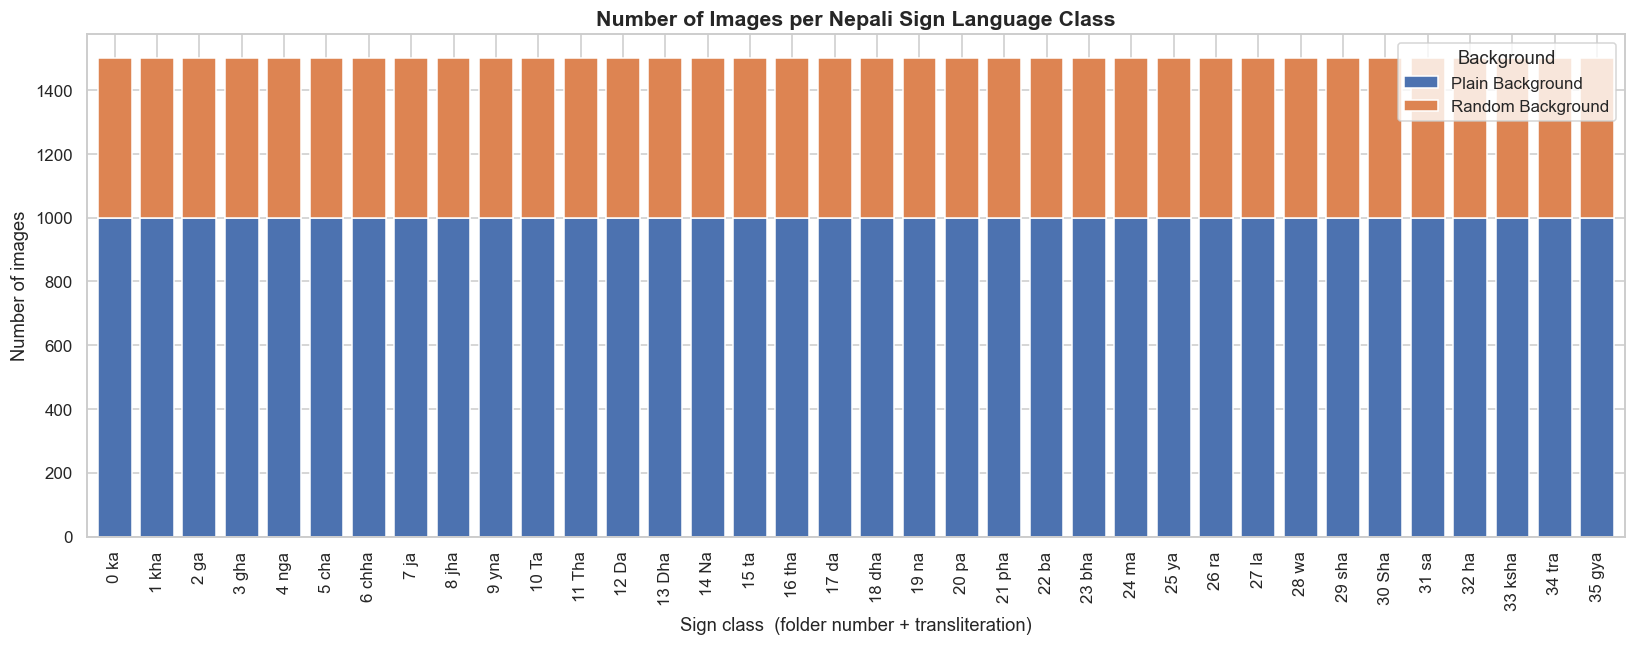

In [12]:
plot_df = (df.groupby(["class_id", "background"]).size()
             .unstack(fill_value=0)
             .rename(index=lambda i: f"{i} {ROMAN_MAP[i]}"))

ax = plot_df.plot(kind="bar", stacked=True, figsize=(15, 6),
                  color=["#4C72B0", "#DD8452"], width=0.8)
ax.set_title("Number of Images per Nepali Sign Language Class", fontsize=14, weight="bold")
ax.set_xlabel("Sign class  (folder number + transliteration)")
ax.set_ylabel("Number of images")
ax.legend(title="Background")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

**Interpretation.** The stacked bars above are all the same height, visually confirming the numeric balance check earlier — no class stands out as under- or over-represented. The chart also shows the split between the two background conditions within each class, which stays proportionally the same (roughly 2:1 Plain:Random) across all 36 characters. Since the classes are this evenly matched, we can trust accuracy as an evaluation metric later without needing to correct for skew.

## 5. Train / Validation / Test Split Plan

Before any model is trained, we fix how the data will be divided. We de-duplicate exact copies first (Section 3), then split the remainder **70% / 15% / 15%** into train / validation / test, stratified by `class_id` so every class is represented in every split.

In [13]:
from sklearn.model_selection import train_test_split

# 1. De-duplicate exact MD5 copies BEFORE splitting, so the same photo never
#    lands in two different splits (md5 was computed in Section 3).
dedup_df = df.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)
print(f"Rows before de-dup : {len(df):,}")
print(f"Rows after de-dup  : {len(dedup_df):,}  ({len(df) - len(dedup_df):,} exact duplicates removed)")

# 2. Stratified 70/15/15 split by class_id.
train_df, temp_df = train_test_split(
    dedup_df, test_size=0.30, stratify=dedup_df["class_id"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class_id"], random_state=RANDOM_SEED
)

print()
print(f"Train : {len(train_df):,} images ({len(train_df) / len(dedup_df):.1%})")
print(f"Val   : {len(val_df):,} images ({len(val_df) / len(dedup_df):.1%})")
print(f"Test  : {len(test_df):,} images ({len(test_df) / len(dedup_df):.1%})")

# 3. Per-class counts in each split, to confirm stratification worked.
split_table = pd.DataFrame({
    "class_id": range(n_classes),
    "roman": [ROMAN_MAP[i] for i in range(n_classes)],
    "train": train_df["class_id"].value_counts().reindex(range(n_classes), fill_value=0).values,
    "val": val_df["class_id"].value_counts().reindex(range(n_classes), fill_value=0).values,
    "test": test_df["class_id"].value_counts().reindex(range(n_classes), fill_value=0).values,
})
print()
print("Per-class counts by split (min/max should be tight if stratification worked):")
for split_name in ["train", "val", "test"]:
    print(f"  {split_name:>5}: min={split_table[split_name].min()}, max={split_table[split_name].max()}")
split_table.head()

# 4. Background-type ratio within each split (both conditions should be present
#    everywhere, close to the dataset's overall ~2:1 Plain:Random ratio).
print()
print("Background mix per split:")
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    bg_ratio = split["background"].value_counts(normalize=True)
    mix = ", ".join(f"{bg}={pct:.1%}" for bg, pct in bg_ratio.items())
    print(f"  {name:>5}: {mix}")

Rows before de-dup : 54,000
Rows after de-dup  : 53,329  (671 exact duplicates removed)

Train : 37,330 images (70.0%)
Val   : 7,999 images (15.0%)
Test  : 8,000 images (15.0%)

Per-class counts by split (min/max should be tight if stratification worked):
  train: min=921, max=1050
    val: min=198, max=225
   test: min=197, max=225

Background mix per split:
  train: Plain Background=67.1%, Random Background=32.9%
    val: Plain Background=67.0%, Random Background=33.0%
   test: Plain Background=67.4%, Random Background=32.6%


**Interpretation.** We stratify the split on `class_id` so all 36 classes appear in every split in the same proportion as the full dataset; since the model will be evaluated per class, this makes validation/test accuracy a reliable estimate for every character, not just the average. We don't stratify on `background` directly, but the per-split check above shows random assignment still keeps both Plain and Random Background close to the dataset's overall ratio in every split — important because Random Background is the harder, more realistic case. A time-based split isn't meaningful here, since images carry no capture timestamp, only a filename order that reflects burst-capture sequence rather than a real time axis. A signer-based split — the strongest test of generalising to a new person — isn't possible either, because `df` has no signer/user-ID column and neither the README nor the source paper documents how many individuals contributed images; exact-duplicate removal is therefore the best available safeguard against leakage between splits.

## 6. Image Size & Channel Distribution + Target Resolution

We check image dimensions, aspect ratio and colour channels, both numerically and visually, then use those findings to choose a target resolution for the next assignment.

### Numeric summary

In [14]:
ok = df[df["read_error"].isna()].copy()
ok["aspect_ratio"] = ok["width"] / ok["height"]
ok["megapixels"] = ok["width"] * ok["height"] / 1e6

print("Width  — min/max/mean : "
      f"{ok['width'].min()} / {ok['width'].max()} / {ok['width'].mean():.1f}")
print("Height — min/max/mean : "
      f"{ok['height'].min()} / {ok['height'].max()} / {ok['height'].mean():.1f}")
print("Aspect ratio (w/h)   — min/max : "
      f"{ok['aspect_ratio'].min():.3f} / {ok['aspect_ratio'].max():.3f}")
print("Distinct resolutions :", dict(Counter(zip(ok["width"], ok["height"]))))
print("Colour channels      :", dict(Counter(ok["channels"])))

Width  — min/max/mean : 300 / 300 / 300.0
Height — min/max/mean : 300 / 300 / 300.0
Aspect ratio (w/h)   — min/max : 1.000 / 1.000
Distinct resolutions : {(300, 300): 54000}
Colour channels      : {3: 54000}


### Visual check: resolution and aspect-ratio distribution

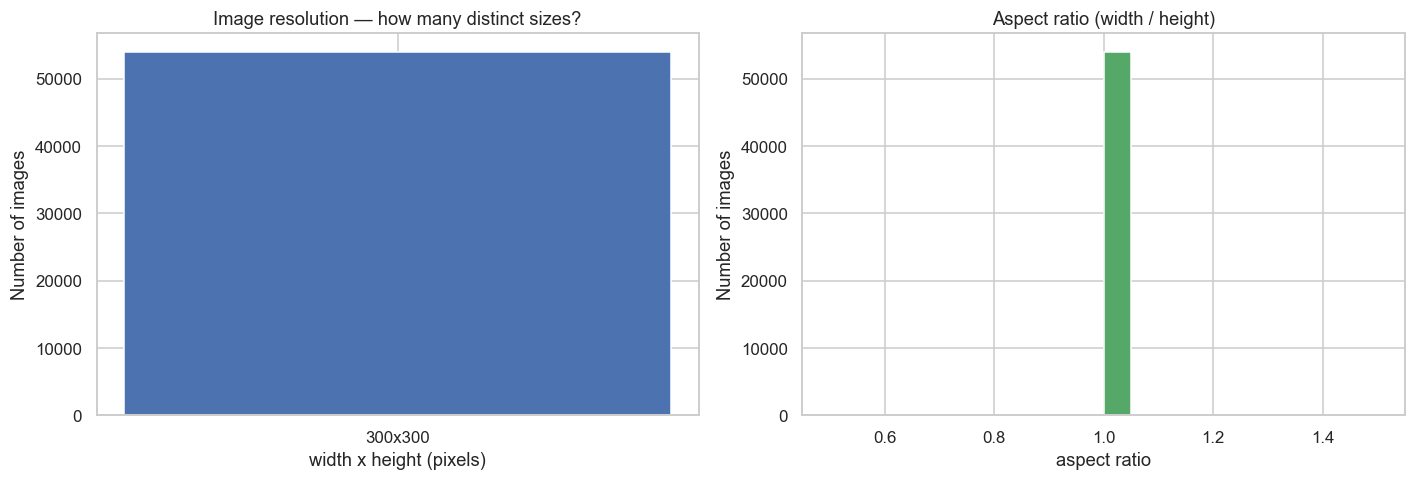

In [15]:
res_counts = Counter(f"{w}x{h}" for w, h in zip(ok["width"], ok["height"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(res_counts.keys(), res_counts.values(), color="#4C72B0", width=0.4)
ax[0].set_title("Image resolution — how many distinct sizes?")
ax[0].set_ylabel("Number of images")
ax[0].set_xlabel("width x height (pixels)")

ax[1].hist(ok["aspect_ratio"], bins=20, color="#55A868")
ax[1].set_title("Aspect ratio (width / height)")
ax[1].set_xlabel("aspect ratio")
ax[1].set_ylabel("Number of images")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "image_dimensions.png"), bbox_inches="tight")
plt.show()

**Interpretation.** All images share a single resolution (300×300) and are square (aspect ratio 1.0), 3-channel RGB — both the numeric summary above and the two plots (which each collapse to a single bar, since there's no variation to show) confirm this consistently. Because the images are already uniform, the only geometric preprocessing the later model will need is a resize to the network's expected input size; there's no cropping or cleaning to do for image size.

**Target resolution for the next assignment.** We will resize images to **224×224** for the CNN classifier. This matches the input size expected by common ImageNet-pretrained backbones (e.g. MobileNetV2, ResNet50 – the two architectures the source paper itself fine-tunes), which keeps transfer learning available, while still shrinking the native 300×300 images enough to reduce memory and training time without discarding the fine hand-shape detail the classifier needs.

## 7. Grid of Samples per Class

This section shows one representative image per class to get a first visual sense of the signs, followed by a closer look at how much a single class varies from photo to photo.

### One sample image per class

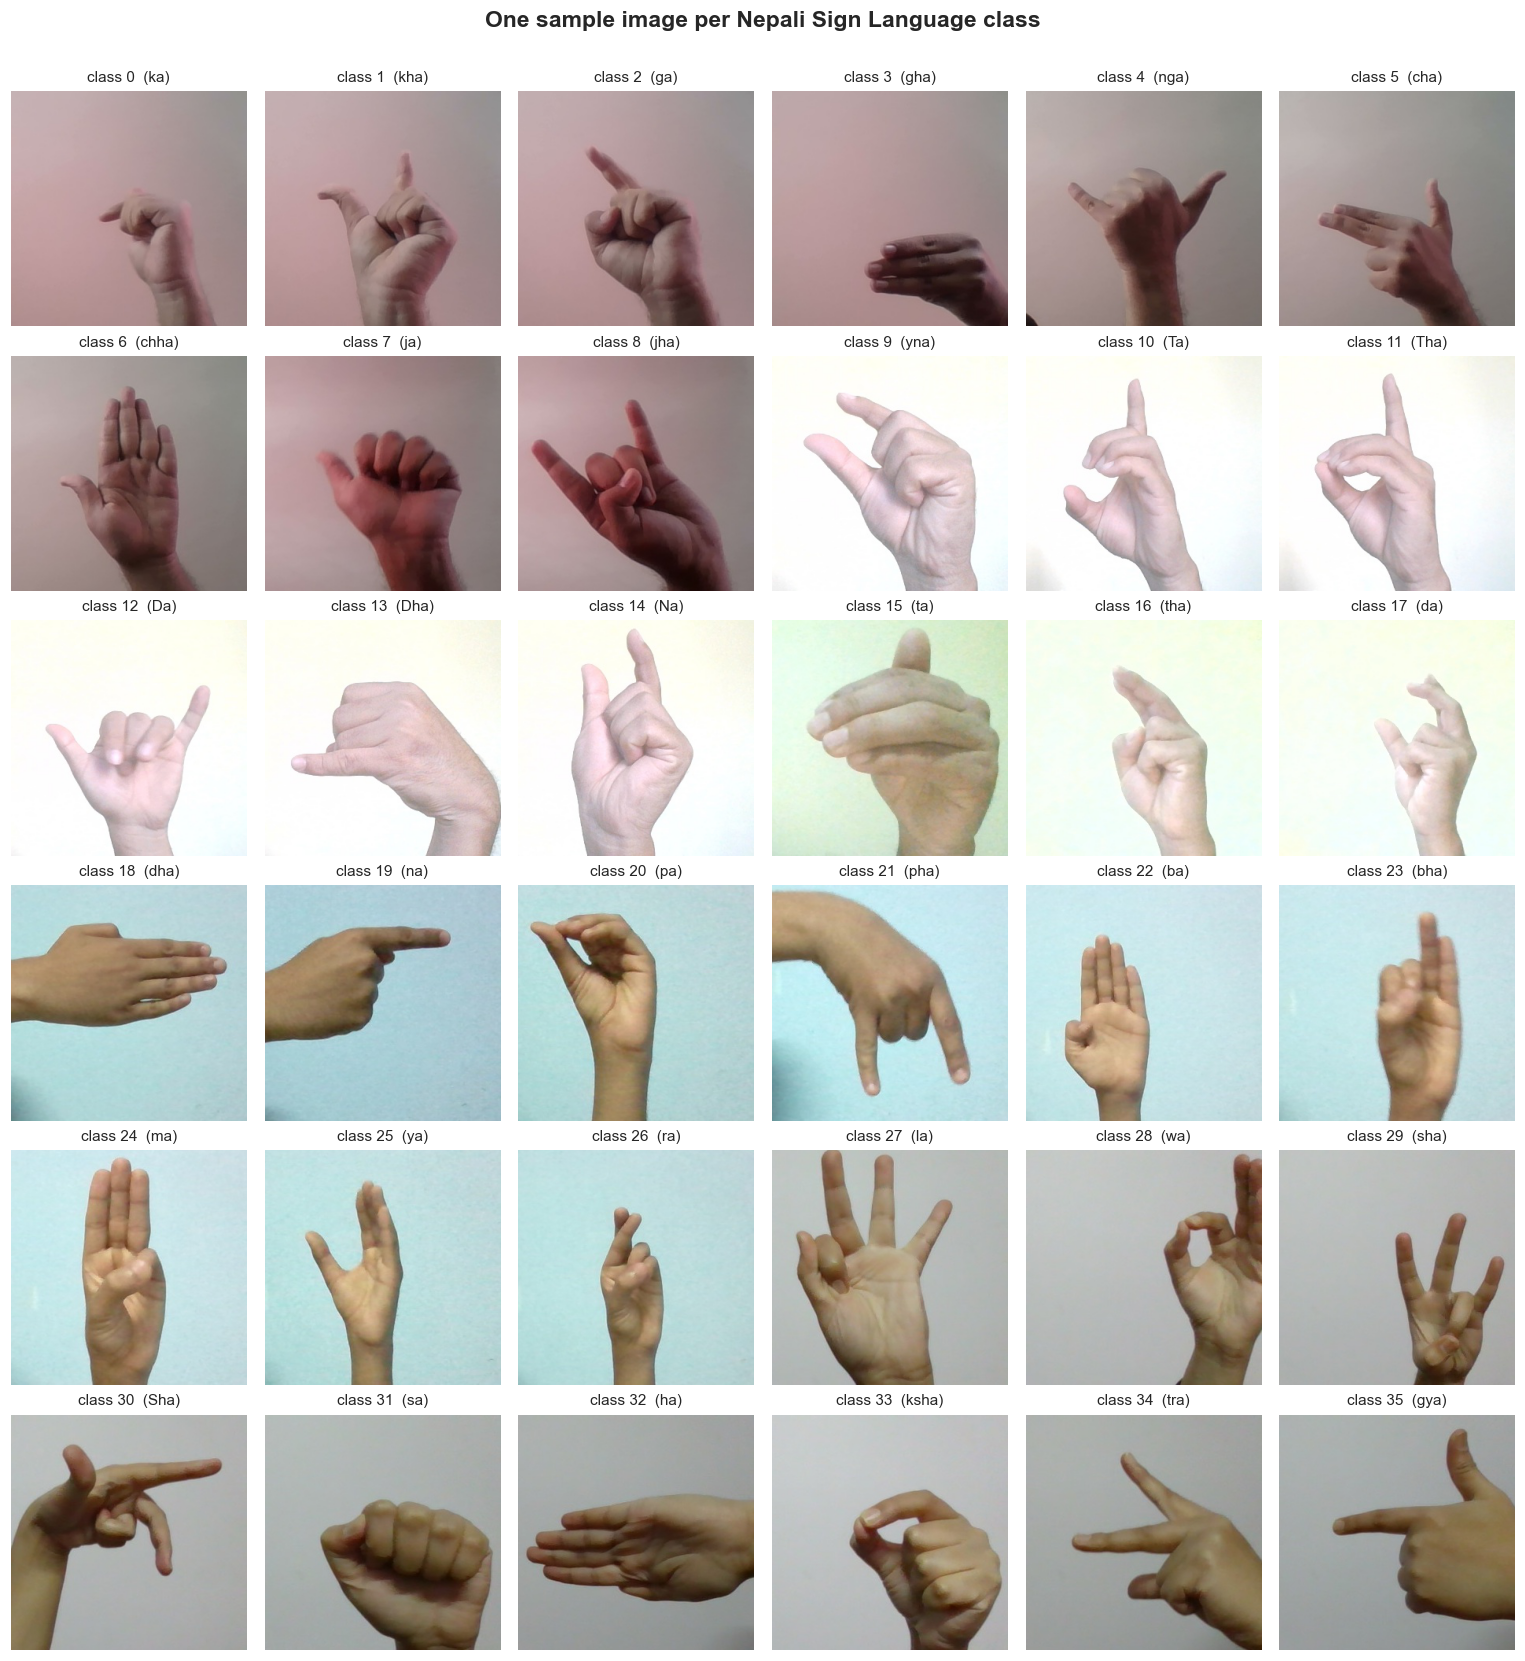

In [16]:
fig, axes = plt.subplots(6, 6, figsize=(14, 15))
for ax, cls in zip(axes.ravel(), range(n_classes)):
    row = df[df["class_id"] == cls].sample(1, random_state=RANDOM_SEED).iloc[0]
    ax.imshow(Image.open(row["filepath"]))
    ax.set_title(f"class {cls}  ({ROMAN_MAP[cls]})", fontsize=10)
    ax.axis("off")
fig.suptitle("One sample image per Nepali Sign Language class", fontsize=15, weight="bold", y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sample_images.png"), bbox_inches="tight")
plt.show()

**Interpretation.** Looking across the grid above, each image is a single hand roughly centred and filling most of the frame, with clearly different finger configurations and orientations across most characters. This confirms the task is genuinely about hand shape rather than pose or framing, since those stay fairly constant. A few pairs do look visually similar, though — for example the retroflex/dental groups — and these are the kind of fine-grained confusion a classifier is likely to struggle with, so per-class error analysis, not just overall accuracy, will matter later.

### Within-class variation (a closer look)

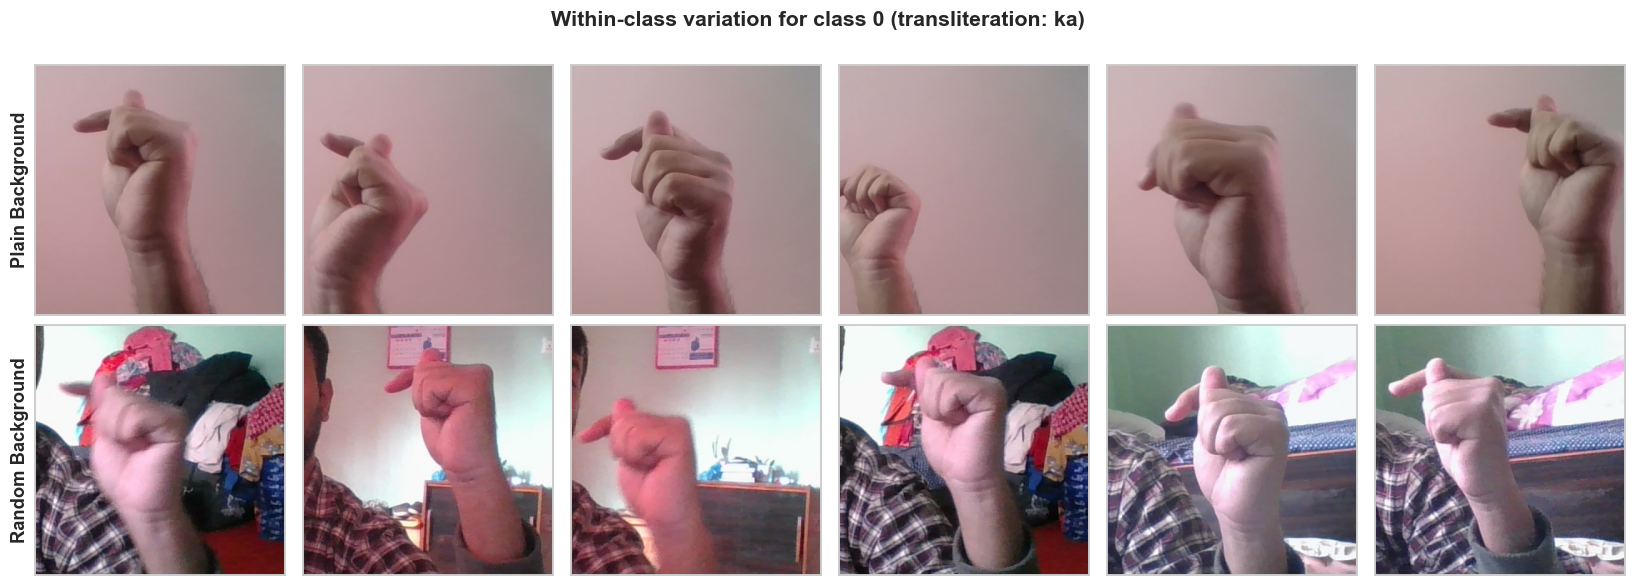

In [17]:
demo_cls = 0
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for j, bg in enumerate(["Plain Background", "Random Background"]):
    subset = df[(df["class_id"] == demo_cls) & (df["background"] == bg)]
    subset = subset.sample(min(6, len(subset)), random_state=RANDOM_SEED)
    for ax, (_, r) in zip(axes[j], subset.iterrows()):
        ax.imshow(Image.open(r["filepath"]))
        ax.set_xticks([]); ax.set_yticks([])
    axes[j, 0].set_ylabel(bg, fontsize=12, weight="bold")
fig.suptitle(f"Within-class variation for class {demo_cls} "
             f"(transliteration: {ROMAN_MAP[demo_cls]})",
             fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "within_class_variation.png"), bbox_inches="tight")
plt.show()

**Interpretation.** Comparing the six examples in each row above, the hand shape for this character stays consistent, but hand size, position, skin tone and lighting all vary from photo to photo — and in the Random Background row, the scene behind the hand changes too. This is expected: the images were captured across many individual shots rather than a single controlled take, so some natural variation is unavoidable. That variety is actually useful for training, since a model exposed to it during learning should generalise better to new photos than one trained on near-identical, tightly controlled images.

## 8. Mean Image per Class

Averaging many images of the same class pixel-by-pixel shows how consistently the hand is positioned and shaped within that class: a sharp mean image means the hand lands in roughly the same place and pose every time, while a blurry mean image means it moves around a lot from photo to photo.

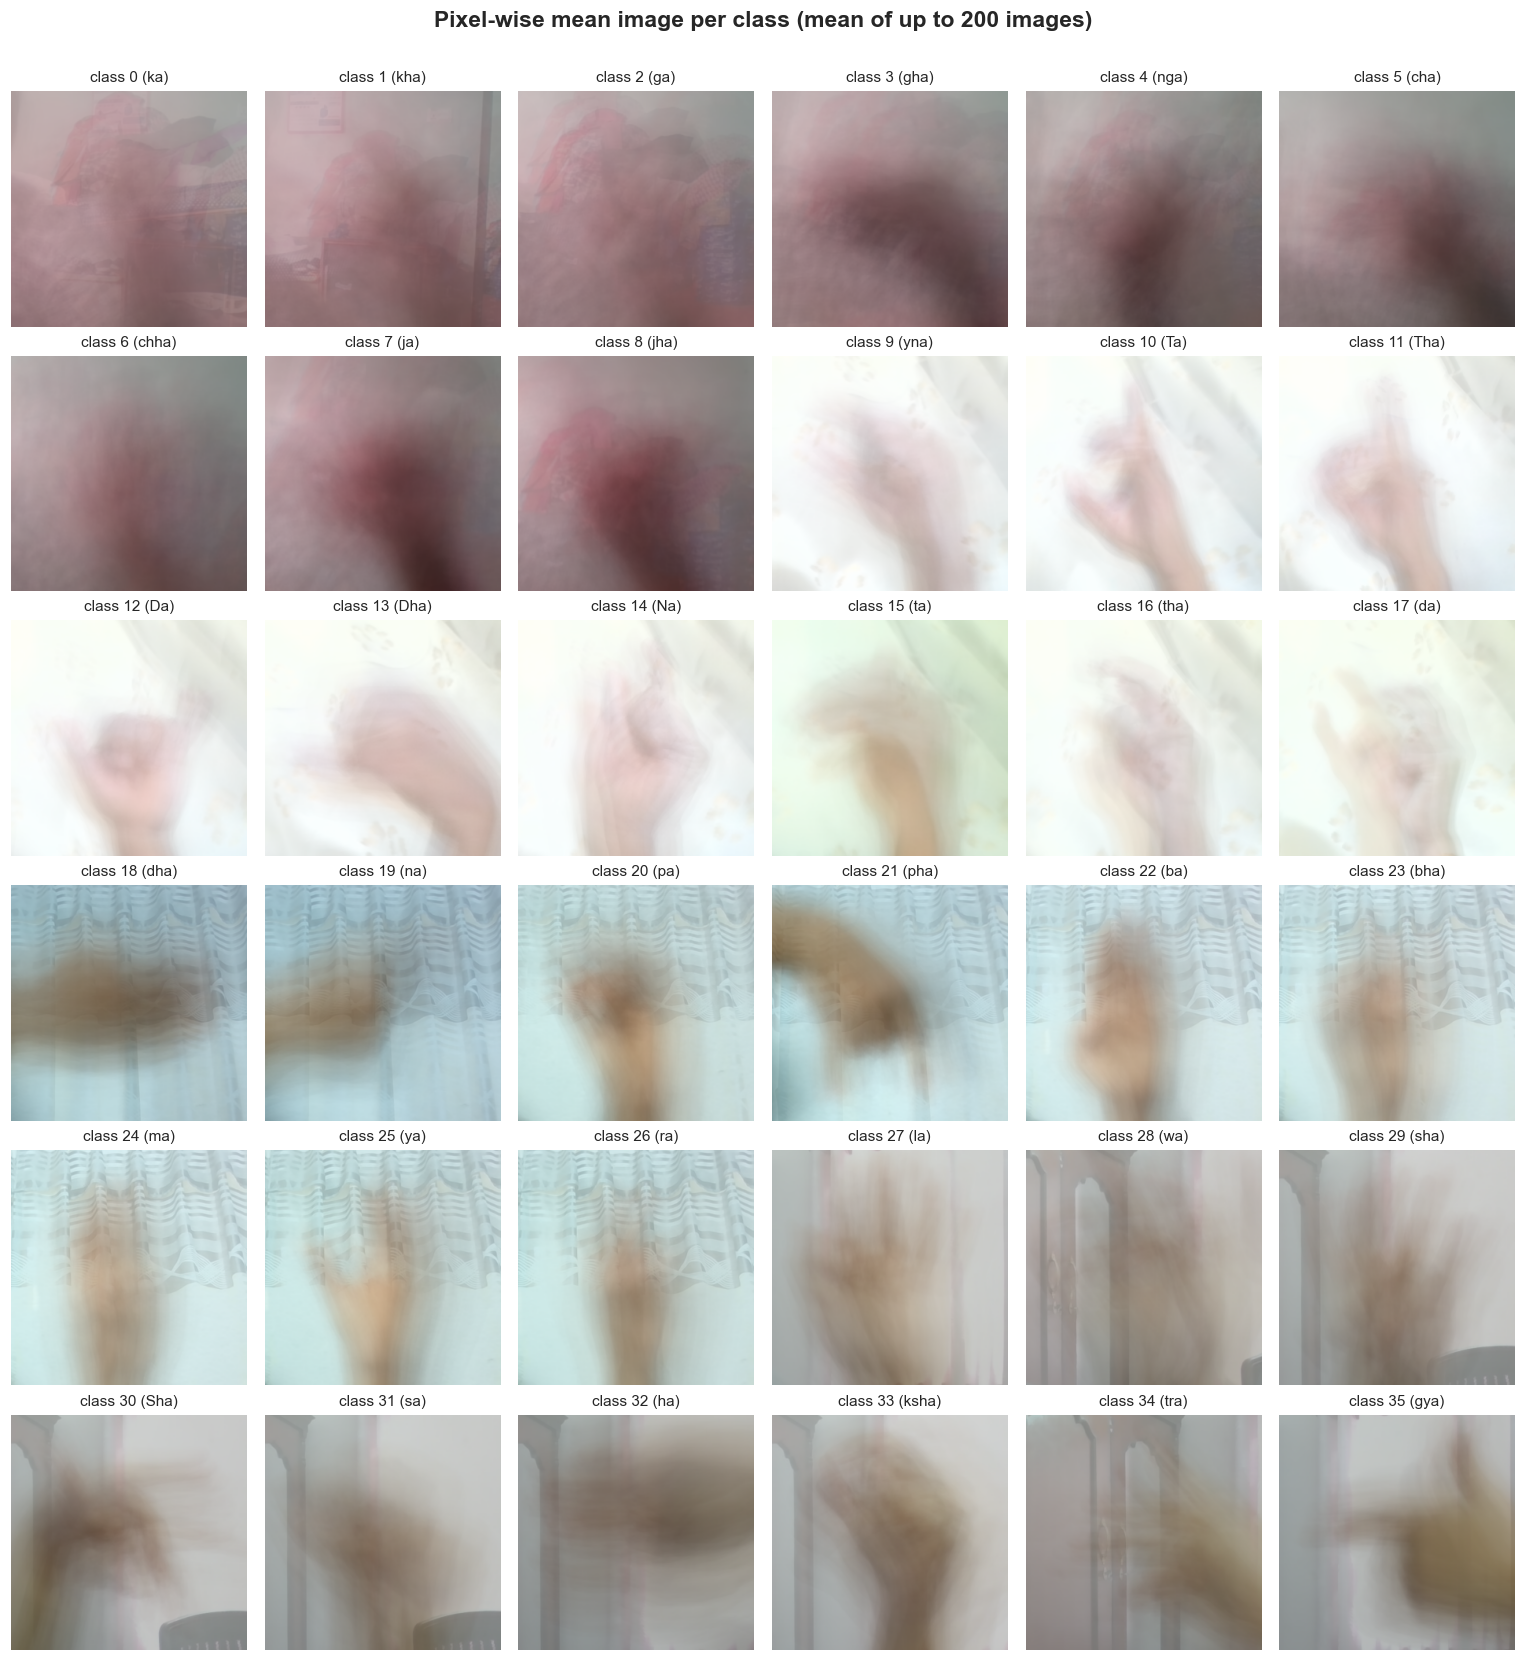

Sharpest mean images (most consistent hand position/pose):
  class 24 (   ma): sharpness = 2.09
  class 26 (   ra): sharpness = 2.09
  class 23 (  bha): sharpness = 2.08
  class 25 (   ya): sharpness = 2.02
  class 22 (   ba): sharpness = 1.98
Blurriest mean images (most within-class position/pose variation):
  class  6 ( chha): sharpness = 0.50
  class  5 (  cha): sharpness = 0.59
  class 12 (   Da): sharpness = 0.59
  class 15 (   ta): sharpness = 0.61
  class 17 (   da): sharpness = 0.61


In [18]:
MEAN_SAMPLE_N = 200
mean_images = []
for cls in range(n_classes):
    cls_paths = df[df["class_id"] == cls]["filepath"]
    n = min(MEAN_SAMPLE_N, len(cls_paths))
    sample_paths = cls_paths.sample(n, random_state=RANDOM_SEED)
    arrs = np.stack([
        np.asarray(Image.open(p).convert("RGB"), dtype=np.float32) for p in sample_paths
    ])
    mean_images.append(arrs.mean(axis=0))

fig, axes = plt.subplots(6, 6, figsize=(14, 15))
for ax, cls, mean_img in zip(axes.ravel(), range(n_classes), mean_images):
    ax.imshow(mean_img.astype(np.uint8))
    ax.set_title(f"class {cls} ({ROMAN_MAP[cls]})", fontsize=10)
    ax.axis("off")
fig.suptitle(f"Pixel-wise mean image per class (mean of up to {MEAN_SAMPLE_N} images)",
             fontsize=15, weight="bold", y=1.005)
plt.tight_layout()
plt.show()

# Objective sharpness proxy: mean gradient magnitude of each mean image
# (higher = sharper/more consistent hand position, lower = blurrier/more variation)
def sharpness_score(img):
    gray = img.mean(axis=2)
    gy, gx = np.gradient(gray)
    return float(np.sqrt(gx ** 2 + gy ** 2).mean())

sharpness = np.array([sharpness_score(m) for m in mean_images])
order = np.argsort(sharpness)
print("Sharpest mean images (most consistent hand position/pose):")
for cls in order[-5:][::-1]:
    print(f"  class {cls:>2} ({ROMAN_MAP[cls]:>5}): sharpness = {sharpness[cls]:.2f}")
print("Blurriest mean images (most within-class position/pose variation):")
for cls in order[:5]:
    print(f"  class {cls:>2} ({ROMAN_MAP[cls]:>5}): sharpness = {sharpness[cls]:.2f}")

**Interpretation.** The sharpness scores above show this varies a lot by class: some mean images retain a clearly defined hand silhouette after averaging 200 photos, while others blur out almost completely. A sharp mean image means the hand lands in roughly the same position, size and pose every time for that class; a blurry one means it moves around a lot from photo to photo. Since several classes fall into the blurry category, positional and scale invariance can't be assumed for the dataset as a whole, so the model will need geometric augmentation — random crop, small translation, scale and rotation jitter — to learn hand *shape* rather than a fixed hand *location*, with the blurriest classes needing it most.

## 9. Pixel Intensity Histograms per Class

We look at overall pixel intensity as context, then break it down per class to check whether intensity is a class-specific signal.

### Overall and per-channel distribution (context)

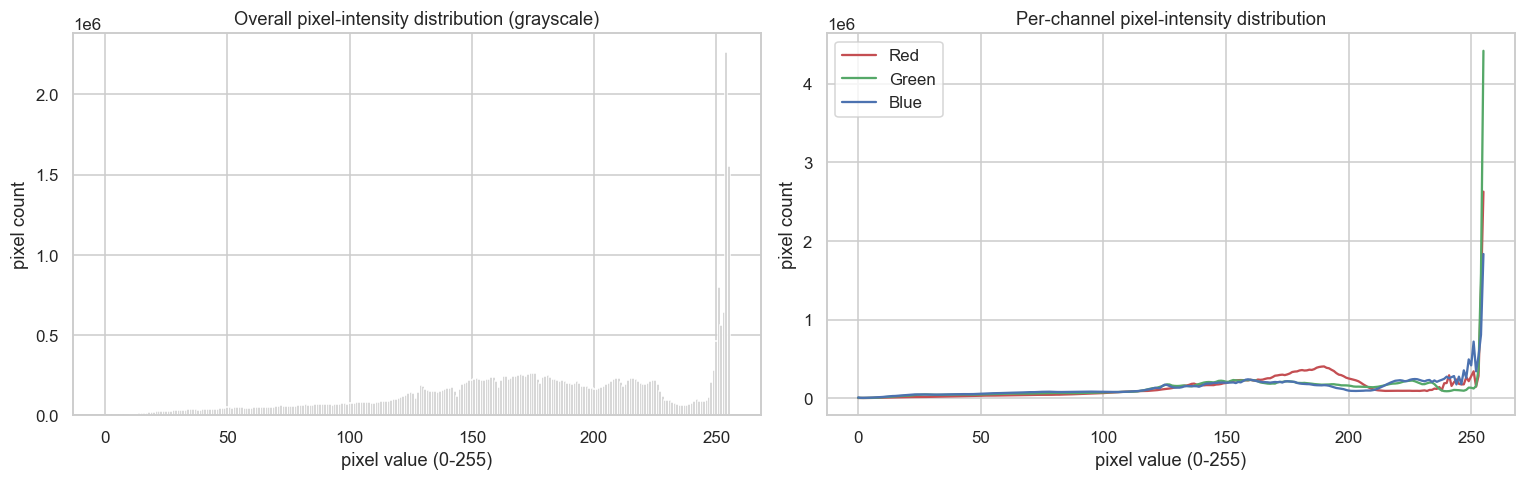

all: mean=177.15  std= 59.69  min=0  max=255
  R: mean=180.00  std= 53.84  min=0  max=255
  G: mean=176.37  std= 63.14  min=0  max=255
  B: mean=173.46  std= 64.88  min=0  max=255


In [19]:
# Accumulate a pixel histogram over a random sample of images
hist_r = np.zeros(256); hist_g = np.zeros(256); hist_b = np.zeros(256); hist_gray = np.zeros(256)
pix_sample = df[df["read_error"].isna()].sample(400, random_state=RANDOM_SEED)
for _, r in pix_sample.iterrows():
    a = np.asarray(Image.open(r["filepath"]).convert("RGB"))
    hist_r += np.bincount(a[:, :, 0].ravel(), minlength=256)
    hist_g += np.bincount(a[:, :, 1].ravel(), minlength=256)
    hist_b += np.bincount(a[:, :, 2].ravel(), minlength=256)
    hist_gray += np.bincount(np.asarray(Image.open(r["filepath"]).convert("L")).ravel(), minlength=256)

bins = np.arange(256)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(bins, hist_gray, color="#555555")
ax[0].set_title("Overall pixel-intensity distribution (grayscale)")
ax[0].set_xlabel("pixel value (0-255)"); ax[0].set_ylabel("pixel count")

ax[1].plot(bins, hist_r, color="#C44E52", label="Red")
ax[1].plot(bins, hist_g, color="#55A868", label="Green")
ax[1].plot(bins, hist_b, color="#4C72B0", label="Blue")
ax[1].set_title("Per-channel pixel-intensity distribution")
ax[1].set_xlabel("pixel value (0-255)"); ax[1].set_ylabel("pixel count")
ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pixel_intensity.png"), bbox_inches="tight")
plt.show()

for name, h in [("all", hist_gray), ("R", hist_r), ("G", hist_g), ("B", hist_b)]:
    m = (bins * h).sum() / h.sum()
    var = ((bins - m) ** 2 * h).sum() / h.sum()
    print(f"{name:>3}: mean={m:6.2f}  std={var**0.5:6.2f}  min={bins[h>0].min()}  max={bins[h>0].max()}")

**Interpretation.** The histograms above show intensities spanning the full 0–255 range but skewed towards the bright end, which fits with the light backgrounds and well-lit hands seen in the sample images. The per-channel means also show red sitting slightly above green and blue, giving the images a mild warm tint from a mix of skin tone and indoor lighting. None of this suggests unusual outliers or a need for special handling — pixel values are well spread across the range, so a simple divide-by-255 (or per-channel standardisation) will be enough normalisation for the model.

### Per-class distribution (main result)

Above, we looked at the overall pixel-intensity distribution across a random sample. Here we compute the same grayscale histogram separately for each of the 36 classes, to check whether intensity varies by character or is dominated by background condition.

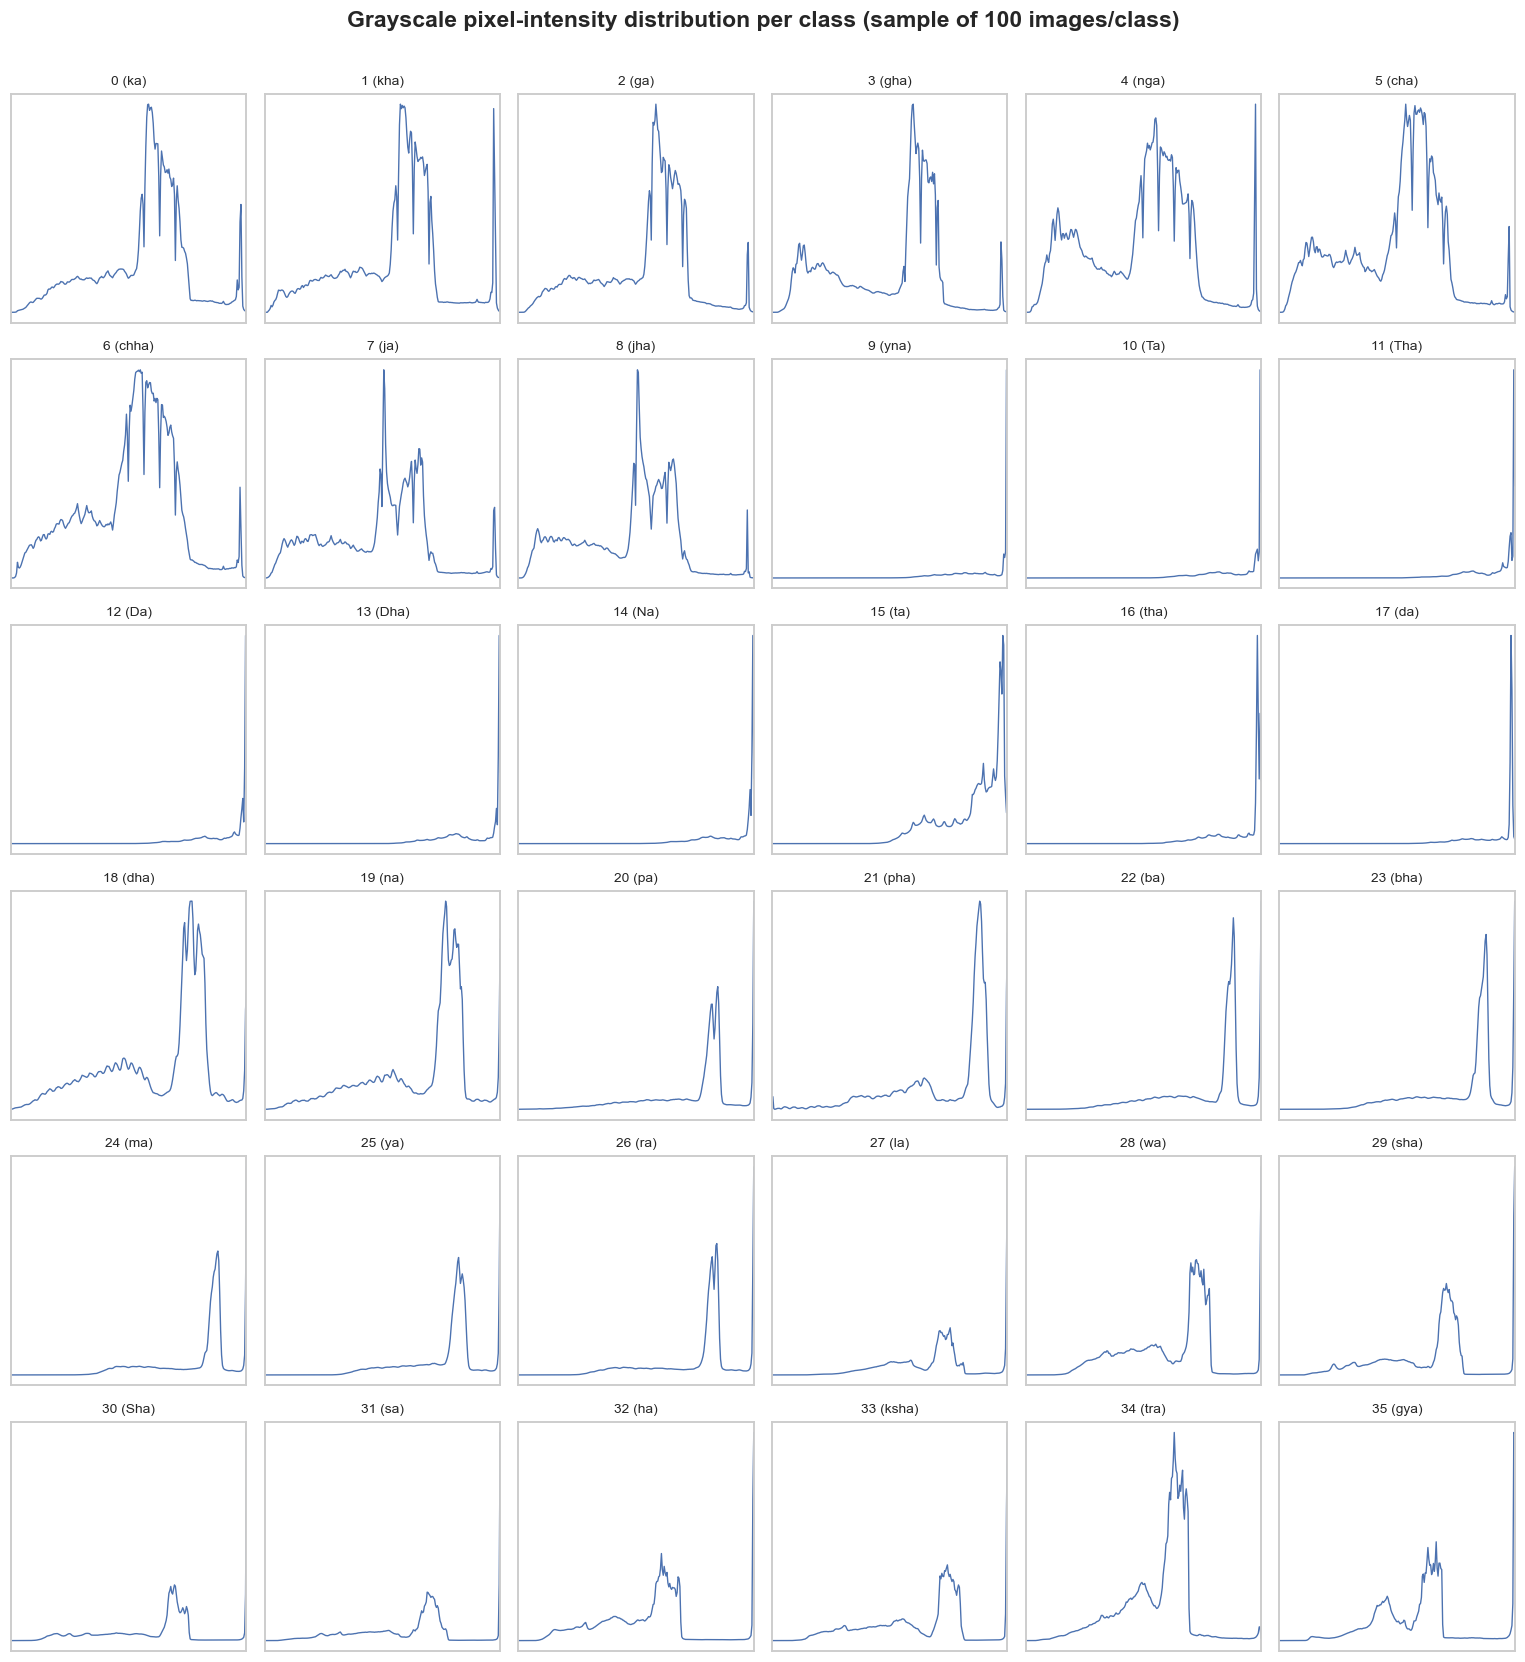

Per-class mean pixel value : min=118.1, max=236.4, spread=118.3
Background-driven gray-scale mean : Plain Background=178.8, Random Background=173.4  (gap=5.5)


In [20]:
N_PER_CLASS = 100
class_hist_gray = np.zeros((n_classes, 256))
for cls in range(n_classes):
    cls_df = df[(df["class_id"] == cls) & (df["read_error"].isna())]
    n = min(N_PER_CLASS, len(cls_df))
    sample = cls_df.sample(n, random_state=RANDOM_SEED)
    for _, r in sample.iterrows():
        a = np.asarray(Image.open(r["filepath"]).convert("L"))
        class_hist_gray[cls] += np.bincount(a.ravel(), minlength=256)

bins = np.arange(256)
fig, axes = plt.subplots(6, 6, figsize=(14, 15), sharex=True)
for ax, cls in zip(axes.ravel(), range(n_classes)):
    ax.plot(bins, class_hist_gray[cls], color="#4C72B0", linewidth=0.9)
    ax.set_title(f"{cls} ({ROMAN_MAP[cls]})", fontsize=9)
    ax.set_xlim(0, 255)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Grayscale pixel-intensity distribution per class (sample of {N_PER_CLASS} images/class)",
             fontsize=15, weight="bold", y=1.005)
plt.tight_layout()
plt.show()

# Quantify class-to-class spread and compare it against the background-driven
# difference. We compute the background-brightness gap directly here (rather
# than reusing the `feat` table from Section 10 Feature Engineering, which is
# not defined yet at this point in the notebook).
norm_hists = class_hist_gray / class_hist_gray.sum(axis=1, keepdims=True)
class_means = (norm_hists * bins).sum(axis=1)

bg_sample = df[df["read_error"].isna()].sample(400, random_state=RANDOM_SEED)
bg_gray_mean = {}
for bg in sorted(bg_sample["background"].unique()):
    paths = bg_sample[bg_sample["background"] == bg]["filepath"]
    vals = [np.asarray(Image.open(p).convert("L"), dtype=np.float32).mean() for p in paths]
    bg_gray_mean[bg] = float(np.mean(vals))
bg_gap = max(bg_gray_mean.values()) - min(bg_gray_mean.values())

print(f"Per-class mean pixel value : min={class_means.min():.1f}, max={class_means.max():.1f}, spread={class_means.max() - class_means.min():.1f}")
print("Background-driven gray-scale mean : " + ", ".join(f"{bg}={m:.1f}" for bg, m in bg_gray_mean.items()) + f"  (gap={bg_gap:.1f})")

**Interpretation.** The comparison above shows per-class intensity varying far more than background condition does — a genuinely unexpected result, since we'd naturally assume Plain vs Random background would be the bigger factor. Because every class shares the same 1000:500 Plain:Random mix, this class-level spread can't be a background artifact; it more likely reflects some classes being captured under different lighting, or having a hand shape/pose that covers more or less of the bright background behind it. This matters for model design: if left uncorrected, a network could partly learn to recognise a class by its typical brightness rather than its hand shape, which would fail to generalise to new photos of the same sign taken under different lighting. Per-image normalisation and brightness/contrast augmentation should therefore be applied regardless of background condition, not just to correct for the Plain/Random split.

## 10. Feature Engineering 

For a classic tabular problem we would hand-craft features, but here the input is a raw image, so the question is whether any manual feature extraction is useful for the EDA and whether it would actually be needed for the model. Below we look at image-level quantities that are cheap to compute — aspect ratio, brightness and per-channel colour — and then state the conclusion.

In [21]:
# Per-image summary features on a random sample (full-dataset pixel loading is unnecessary for EDA)
SAMPLE_N = 1500
sample_paths = df[df["read_error"].isna()].sample(SAMPLE_N, random_state=RANDOM_SEED)

feat_rows = []
for _, r in sample_paths.iterrows():
    arr = np.asarray(Image.open(r["filepath"]).convert("RGB"), dtype=np.float32)
    feat_rows.append({
        "class_id": r["class_id"],
        "background": r["background"],
        "aspect_ratio": r["width"] / r["height"],
        "brightness": arr.mean(),
        "contrast_std": arr.std(),
        "R_mean": arr[:, :, 0].mean(),
        "G_mean": arr[:, :, 1].mean(),
        "B_mean": arr[:, :, 2].mean(),
    })
feat = pd.DataFrame(feat_rows)
feat.describe().round(2)

,class_id,aspect_ratio,brightness,contrast_std,R_mean,G_mean,B_mean
count,1500.00,1500.0,1500.00,1500.00,1500.00,1500.00,1500.00
mean,17.55,1.0,176.34,43.20,179.40,176.35,173.28
std,10.43,0.0,40.62,14.21,37.37,43.93,42.09
min,0.00,1.0,82.91,17.82,94.69,71.05,82.98
25%,9.00,1.0,140.97,31.95,150.21,137.12,134.91
50%,18.00,1.0,168.38,40.48,170.10,170.40,169.16
75%,27.00,1.0,208.67,51.27,209.47,215.30,211.00
max,35.00,1.0,242.82,86.83,246.64,246.53,241.12


In [22]:
print("Aspect ratio — unique values in sample:", sorted(feat["aspect_ratio"].round(3).unique()))
print()
print("Mean pixel value by channel (sample):")
print(feat[["R_mean", "G_mean", "B_mean"]].mean().round(2).to_string())
print()
print("Brightness by background (sample):")
print(feat.groupby("background")["brightness"].agg(["mean", "std"]).round(2).to_string())

Aspect ratio — unique values in sample: [np.float64(1.0)]

Mean pixel value by channel (sample):
R_mean    179.399994
G_mean    176.350006
B_mean    173.279999

Brightness by background (sample):
                         mean    std
background                          
Plain Background   178.740005  39.73
Random Background  171.330002  42.02


**Conclusion on feature engineering.**

- **Aspect ratio** is constant (1.0) across the whole dataset — there's nothing to engineer here.
- **Brightness, contrast and colour** vary a little between images and between the two background conditions, which is useful for understanding the data, but none of them are discriminative features for telling the 36 characters apart — the sign is defined by hand shape, not by overall brightness.
- Hand-crafted features such as edge maps, HOG descriptors or hand-keypoint coordinates are not built here, since this is an image-classification problem and the convolutional network in the next assignment will learn the relevant visual features (edges, finger positions, hand contour) directly from pixels.
- The only preparation the images genuinely need later is routine preprocessing: resizing to the model's input size and scaling pixel values to `[0, 1]` (or standardising them). These are preprocessing steps, not feature engineering, and are left for the modelling assignment.

**Therefore, no manual feature engineering is required.**

## 11. Brightness by Background Condition

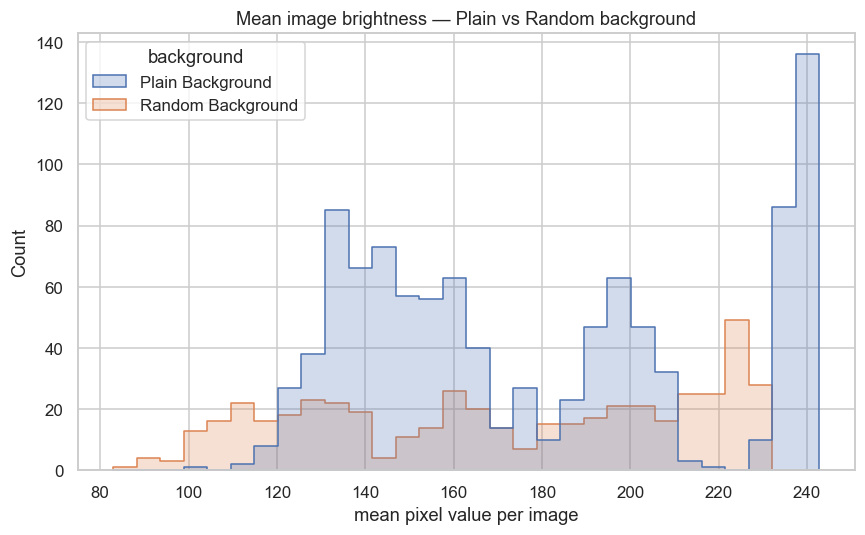

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=feat, x="brightness", hue="background", bins=30,
             element="step", stat="count", common_norm=False, ax=ax)
ax.set_title("Mean image brightness — Plain vs Random background")
ax.set_xlabel("mean pixel value per image")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "brightness_by_background.png"), bbox_inches="tight")
plt.show()

**Interpretation.** The histogram above shows the Plain and Random background brightness distributions overlapping heavily, so brightness alone can't reliably tell the two conditions apart, let alone identify the character. Plain images do show a distinct peak at the very bright end, which comes from the near-white studio-style backdrops used for that condition; Random backgrounds are more spread out since they include varied real-world scenes. Background condition is therefore a real, measurable source of pixel-level variation — though Section 9 found that class identity itself has an even larger effect on intensity, which is the more surprising nuisance factor. Either way, the model's training pipeline needs to be robust to brightness differences that have nothing to do with the sign being made, which is why per-image normalisation and brightness/contrast augmentation are part of the plan.

## 12. Three Findings That Change Model Design

1. **Visually similar character groups will drive most errors, so metrics must be inspected per class, not just as overall accuracy.** Section 7 shows several consonants share similar hand shapes; a single accuracy number would hide a classifier that fails consistently on a few hard classes — a confusion matrix is needed to catch this.
2. **Pixel intensity is not a stable per-class signal, so the model must be trained to ignore it.** Both background condition (Section 11) and, more surprisingly, class identity itself (Section 9) shift image brightness — effects unrelated to hand shape. The pipeline needs per-image normalisation and brightness/contrast augmentation so the model can't shortcut on intensity instead of learning the sign.
3. **Roughly 1% of images are exact duplicate frames, so de-duplication must happen before the split, not after.** Section 3 found these burst-capture duplicates; Section 5 removes them by MD5 before splitting, since splitting first could leak a duplicate into both train and test and inflate accuracy.

## 13. Conclusion / Summary

In [24]:
print("=" * 60)
print("NEPALI SIGN LANGUAGE DATASET — EDA SUMMARY")
print("=" * 60)
print(f"Dataset root           : {DATA_ROOT}")
print(f"Total images           : {n_images:,}  (all JPEG, all readable)")
print(f"Classes                : {n_classes} Devanagari characters (folders 0-35)")
print(f"Background conditions   : Plain ({int((df.background=='Plain Background').sum()):,}) "
      f"+ Random ({int((df.background=='Random Background').sum()):,})")
print(f"Images per class        : {int(counts.min())} (identical for every class -> BALANCED)")
print(f"Image size              : {ok['width'].mode()[0]} x {ok['height'].mode()[0]} px, "
      f"aspect ratio {ok['aspect_ratio'].mean():.2f}")
print(f"Colour                  : {Counter(ok['mode']).most_common(1)[0][0]} "
      f"({int(ok['channels'].mode()[0])} channels)")
print(f"Pixel value range       : 0-255, sample mean ~{feat['brightness'].mean():.0f}")
print(f"Per-channel mean (R/G/B): "
      f"{feat['R_mean'].mean():.1f} / {feat['G_mean'].mean():.1f} / {feat['B_mean'].mean():.1f}")
print(f"Corrupted images        : {len(corrupt)}")
print(f"Empty folders / bad types: {len(empty)} / {len(non_jpg)}")
print(f"Duplicate images        : {n_redundant} redundant copies in {n_dup_groups} groups "
      f"({n_redundant / len(df) * 100:.2f}% of files), all within a single class")
print(f"Note                    : archive/ also stores a byte-identical second copy (NSLv2)")
print(f"Feature engineering     : not required (CNN will learn features from pixels)")
print("=" * 60)

NEPALI SIGN LANGUAGE DATASET — EDA SUMMARY
Dataset root           : archive\NSL\NSL
Total images           : 54,000  (all JPEG, all readable)
Classes                : 36 Devanagari characters (folders 0-35)
Background conditions   : Plain (36,000) + Random (18,000)
Images per class        : 1500 (identical for every class -> BALANCED)
Image size              : 300 x 300 px, aspect ratio 1.00
Colour                  : RGB (3 channels)
Pixel value range       : 0-255, sample mean ~176
Per-channel mean (R/G/B): 179.4 / 176.4 / 173.3
Corrupted images        : 0
Empty folders / bad types: 0 / 0
Duplicate images        : 671 redundant copies in 668 groups (1.24% of files), all within a single class
Note                    : archive/ also stores a byte-identical second copy (NSLv2)
Feature engineering     : not required (CNN will learn features from pixels)


### Findings

- **Dataset size.** 54,000 hand-sign images (JPEG), all readable.
- **Number of classes.** 36 — one per Devanagari consonant character, in numbered folders `0`–`35`; the README gives the folder-to-character mapping used throughout this notebook.
- **Class distribution.** Perfectly balanced: every class has exactly 1500 images (1000 Plain Background + 500 Random Background), so no resampling or class weighting is needed.
- **Image characteristics.** Every image is 300×300 pixels, square, 3-channel RGB. Pixel values use the full 0–255 range, are skewed bright, and carry a slight warm (red) bias.
- **Data quality.** No corrupted files, unexpected file types, empty class folders or missing labels. About 1% of images are exact byte-for-byte duplicates of another image in the *same* class (consecutive burst frames) and should be removed before the train/validation/test split; `archive/` also contains a second, byte-identical copy of the whole dataset (`NSLv2/`), which is ignored here to avoid double-counting.
- **Visual observations.** Signs are centred single-hand gestures. Both background condition and class identity itself are nuisance variables that shift pixel intensity (Sections 9 & 11), and a few character groups are visually similar enough to be likely confusion cases for a classifier.
- **Feature engineering.** Not required — aspect ratio is constant and brightness/colour are not class-discriminative. The convolutional network in the next assignment will learn the visual features directly; the only later preprocessing needed is a resize and pixel scaling.

### Interpretation of Visualizations

- **Class distribution (V1).** All 36 classes are equal in size (1500 images each, split 1000/500 between Plain and Random backgrounds). The data is balanced, so no class is under- or over-represented.
- **Sample images (V2).** The task is single-hand static-sign recognition. Signs are visually distinct overall, but some character groups are similar and will be the hard cases for a classifier.
- **Within-class variation (V2b).** The same sign appears with varied hand size, position, lighting and background — useful natural augmentation the model can learn to be robust to.
- **Mean image per class (V2c).** Averaging images within a class shows how consistently the hand is positioned: sharper mean images mean less positional variation, blurrier ones mean more.
- **Image dimensions (V3).** Perfectly uniform: one resolution, square aspect ratio, 3 RGB channels. Nothing to fix.
- **Pixel / colour distribution (V4).** Full dynamic range, bright-skewed, with a slight warm (red) bias. Standard per-channel scaling is sufficient.
- **Pixel intensity per class (V4b).** Class-level intensity spread is far larger than the Plain-vs-Random background gap — an unexpected result that means brightness-robust training is needed regardless of background condition.
- **Brightness by background (V5).** Plain backgrounds are brighter and more consistent; Random backgrounds add lighting and scene variability. Both this and class identity are nuisance factors for the model to be robust to.

### Suitability for the neural-network assignment

The dataset is well suited for the upcoming CNN work: it is large, perfectly class-balanced, uniform in size and format, and essentially free of quality defects. Two things should carry forward into that assignment: (1) remove the ~1% exact-duplicate images before splitting the data, so identical photos don't appear in both the training and validation/test sets; (2) keep both the Plain and Random background conditions represented in every split, so the model learns to recognise the hand sign itself rather than the background it happens to be photographed against.